<a href="https://colab.research.google.com/github/luckytas96-ux/Proyecto_DS_ParteI_Scalise/blob/main/Copia_de_Proyecto_DS_ParteI_Scalise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto Final - Visualizaciones en Python

#Primera entrega



# **Archivo: Proyecto_DS_ParteI_Scalise.ipynb**

---
---

## **Abstract**

El presente proyecto tiene como propósito analizar el fenómeno del suicidio en la República Argentina a partir del dataset **“Hechos y víctimas de suicidios en la República Argentina. Total nacional”**, disponible en el portal de datos abiertos del gobierno ([datos.gob.ar](https://datos.gob.ar/)). Este conjunto de datos contiene **25 920 registros**, que abarcan el período comprendido entre **2017 y 2023**, con **18 variables** que describen las características del hecho, el contexto en el que ocurrió y los atributos de la persona involucrada. Cada registro representa un evento individual, proporcionando información valiosa para el estudio de **patrones espaciales, temporales y demográficos** del suicidio en el país.

El **objetivo del análisis** es realizar una **exploración sistemática de los datos** mediante técnicas de análisis **univariado, bivariado y multivariado**, con el fin de identificar **tendencias significativas, comportamientos recurrentes y relaciones** entre las distintas variables. A través del análisis de datos se busca obtener una comprensión más profunda del fenómeno, evaluando su **evolución temporal**, las **diferencias por género y grupo etario**, la **distribución geográfica de los casos** y las **modalidades más frecuentes**.

El estudio de este tipo de información resulta de **gran relevancia social**, ya que el suicidio constituye una **problemática de salud pública** que requiere políticas de prevención basadas en evidencia. La posibilidad de examinar **datos abiertos** de manera estructurada y reproducible permite **detectar patrones de riesgo**, **identificar grupos etarios y regiones con mayor incidencia**, y generar **insumos cuantitativos** para el diseño de **intervenciones preventivas**.  
En definitiva, este trabajo busca demostrar cómo el uso de la **analítica de datos** puede contribuir al desarrollo de **estrategias más efectivas y focalizadas** en la prevención del suicidio en Argentina.

---
---

## **Preguntas / Hipótesis de interes**

1.¿Cómo ha sido la evolución de los suicidios a lo largo de los años?

2.¿Qué provincias tienen los mayores casos?

3.¿Cuales son los rangos de edad con mayor cantidad de suicidios?

4.¿Existen diferencias entre hombres y mujeres?

5.¿Hay meses con mayor cantidad de suicidios?

6.¿Cuál es la modalidad más utilizada para llevar a cabo el suicidio?

---
---

## **Objetivo del proyecto**

El objetivo principal de este proyecto es analizar y comprender el comportamiento del suicidio en la República Argentina entre los años 2017 y 2023, aplicando técnicas de análisis exploratorio y visualización de datos para obtener una visión integral del fenómeno del suicidio en Argentina, aportando información que pueda ser útil para la formulación de políticas públicas y programas de prevención basados en evidencia



---
---

## **Visualizacion de datos**

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Cargar Datos
url = "https://raw.githubusercontent.com/luckytas96-ux/Proyecto_DS_ParteI_Scalise/refs/heads/main/dataset_data_science_1.csv"
df = pd.read_csv(url)
df.head()


,id_hecho,tipo_persona_id,provincia_nombre,departamento_id,departamento_nombre,localidad_id,localidad_nombre,anio,mes,fecha_hecho,hora_hecho,tipo_lugar,tipo_lugar_ampliado,modalidad,motivo_origen_registro,suicida_sexo,suicida_tr_edad,suicida_18_años_o_mas
0,8529,Suicida idRegistro 20712,La Pampa,42002,Norte (General Pico),105030,General Pico,2017,1,8/1/2017,13:25:00,Vía pública,Vía pública,Ahorcamiento,Intervención policial,Masculino,20-24,Si
1,8530,Suicida idRegistro 20713,La Pampa,42003,Sur (General Acha),70030,Guatraché,2017,1,9/1/2017,01:00:00,Domicilio particular,Domicilio particular,Arma de fuego,Intervención policial,Masculino,55-59,Si
2,8569,Suicida idRegistro 20752,Santa Cruz,78021,Güer Aike,60,28 de Noviembre,2017,1,1/1/2017,19:00:00,Vía pública,Vía pública,Ahorcamiento,Denuncia particular,Masculino,15-19,No
3,8705,Suicida idRegistro 20894,Neuquén,58035,Confluencia,70,Neuquén,2017,1,31/1/2017,17:30:00,Otro Lugar ( Especificar ),Hotel/Motel/Hospedaje temporario,Arma de fuego,Intervención policial,Masculino,20-24,Si
4,8706,Suicida idRegistro 20895,Neuquén,58035,Confluencia,100,Plottier,2017,1,31/1/2017,22:40:00,Domicilio particular,Domicilio particular,Ahorcamiento,Intervención policial,Masculino,20-24,Si


---
---

## **Missing Values**

In [26]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0
tipo_lugar_ampliado,2


Se observa que hay valores faltantes en la columna de tipo_lugar_ampliado. Se reemplazaran por "sin determinar"

In [27]:
df['tipo_lugar_ampliado'] = df['tipo_lugar_ampliado'].fillna('sin determinar')

Si volvemos a ejecutar el código, veremos que ya no hay valores nulos

In [28]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0


---
---

## **Análisis univariado**

Evolución de la cantidad de suicidios a lo largo de los años

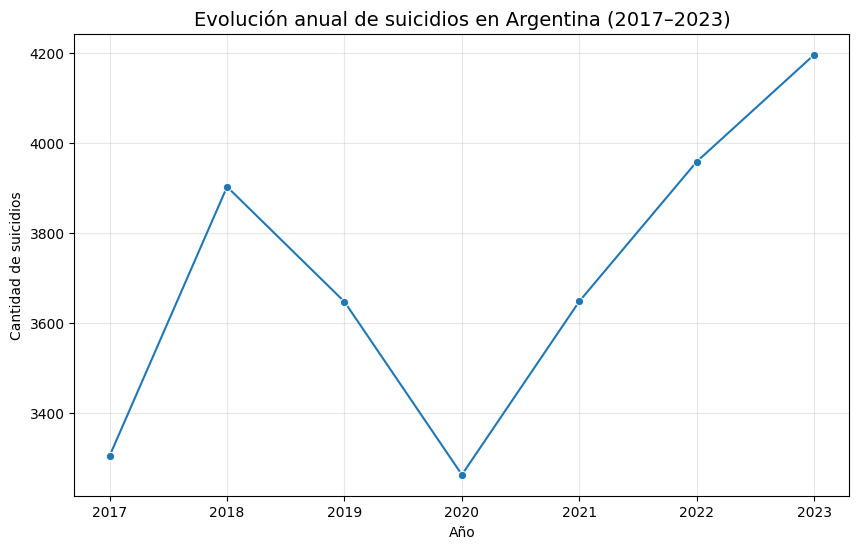

In [29]:
suicidios_por_anio = df.groupby('anio').size().reset_index(name='cantidad_casos')
plt.figure(figsize=(10, 6))
sns.lineplot(data=suicidios_por_anio, x='anio', y='cantidad_casos', marker='o')
plt.title('Evolución anual de suicidios en Argentina (2017–2023)', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Cantidad de suicidios')
plt.grid(True, alpha=0.3)
plt.show()

---
---

## **Analisis bivariado**

Cantidad de suicidios por mes en cada provincia

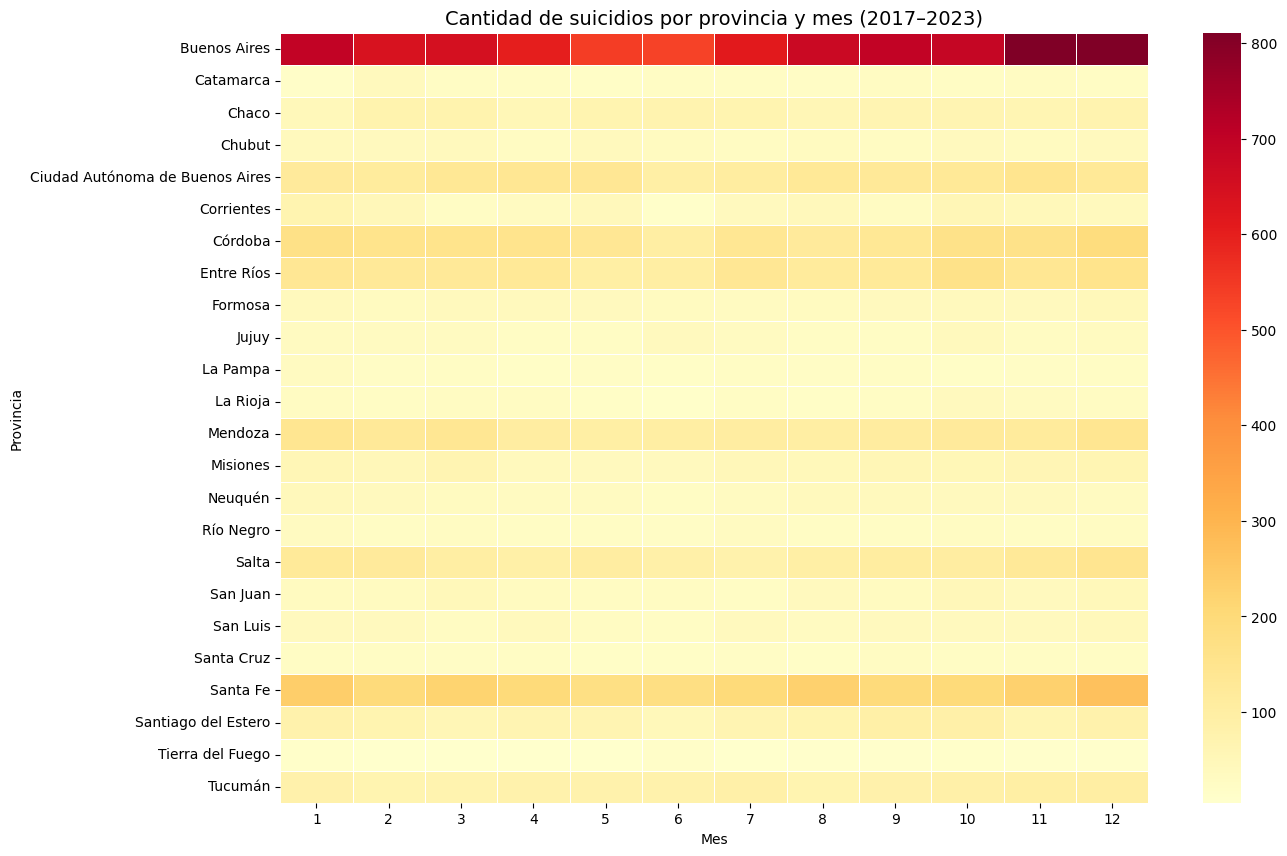

In [30]:
pivot_prov_mes = df.groupby(['provincia_nombre', 'mes']).size().reset_index(name='cantidad_casos')
tabla_calor = pivot_prov_mes.pivot(index='provincia_nombre', columns='mes', values='cantidad_casos').fillna(0)
plt.figure(figsize=(14, 10))
sns.heatmap(tabla_calor, cmap='YlOrRd', linewidths=0.5)
plt.title('Cantidad de suicidios por provincia y mes (2017–2023)', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Provincia')
plt.show()

---
---

## **Análisis multivariado**

Rango de edad vs Sexo vs Modalidad

📋 Rangos de edad incluidos en el gráfico:
• 20-24
• 25-29
• 15-19
• 30-34
• 35-39


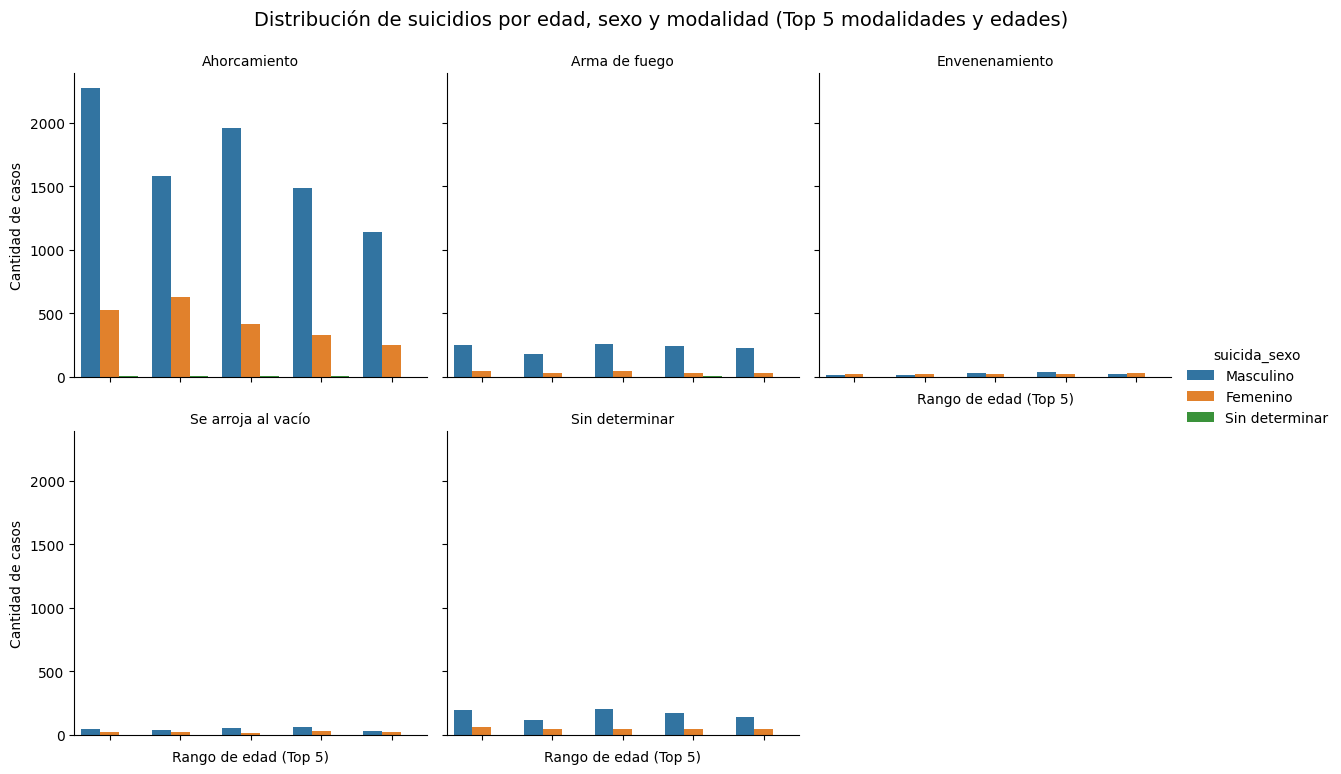

In [31]:
top5_modalidades = df['modalidad'].value_counts().nlargest(5).index
top5_edades = df['suicida_tr_edad'].value_counts().nlargest(5).index
df_top = df[(df['modalidad'].isin(top5_modalidades)) & (df['suicida_tr_edad'].isin(top5_edades))]
g = sns.catplot(
    data=df_top,
    x='suicida_tr_edad',
    hue='suicida_sexo',
    col='modalidad',
    kind='count',
    col_wrap=3,
    height=4,
    aspect=1
)
g.set_titles("{col_name}")
g.set_axis_labels("Rango de edad (Top 5)", "Cantidad de casos")
g.set_xticklabels(rotation=45)
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Distribución de suicidios por edad, sexo y modalidad (Top 5 modalidades y edades)", fontsize=14)
print("📋 Rangos de edad incluidos en el gráfico:")
for edad in top5_edades:
    print(f"• {edad}")
plt.show()

---
---

## **Conclusiones preliminares**

1.La cantidad de suicidios ha ido en aumento desde 2021 en adelante

2.La provincia de Buenos Aires tiene por mucha diferencia la mayor cantidad de suicidios.

3.Entre los 15 y 39 años se producen la mayor cantidad de suicidios.

4.Se observa una diferencia notoria entre hombres y mujeres, siendo los primeros los más afectados.

5.No se observan cambios relevantes entre los distintos meses.

6.La mayor cantidad de suicidios son llevados a cabo mediante el ahorcamiento.

---
---

## **Acciones que podría realizar para mi dataset**

In [32]:
# Eliminar columnas con información poco útil para el análisis

df.drop(columns=['motivo_origen_registro'], inplace=True)



In [33]:
df.head()

,id_hecho,tipo_persona_id,provincia_nombre,departamento_id,departamento_nombre,localidad_id,localidad_nombre,anio,mes,fecha_hecho,hora_hecho,tipo_lugar,tipo_lugar_ampliado,modalidad,suicida_sexo,suicida_tr_edad,suicida_18_años_o_mas
0,8529,Suicida idRegistro 20712,La Pampa,42002,Norte (General Pico),105030,General Pico,2017,1,8/1/2017,13:25:00,Vía pública,Vía pública,Ahorcamiento,Masculino,20-24,Si
1,8530,Suicida idRegistro 20713,La Pampa,42003,Sur (General Acha),70030,Guatraché,2017,1,9/1/2017,01:00:00,Domicilio particular,Domicilio particular,Arma de fuego,Masculino,55-59,Si
2,8569,Suicida idRegistro 20752,Santa Cruz,78021,Güer Aike,60,28 de Noviembre,2017,1,1/1/2017,19:00:00,Vía pública,Vía pública,Ahorcamiento,Masculino,15-19,No
3,8705,Suicida idRegistro 20894,Neuquén,58035,Confluencia,70,Neuquén,2017,1,31/1/2017,17:30:00,Otro Lugar ( Especificar ),Hotel/Motel/Hospedaje temporario,Arma de fuego,Masculino,20-24,Si
4,8706,Suicida idRegistro 20895,Neuquén,58035,Confluencia,100,Plottier,2017,1,31/1/2017,22:40:00,Domicilio particular,Domicilio particular,Ahorcamiento,Masculino,20-24,Si


---
---

## **Aplicar algun metodo de outliers detection**

In [34]:
original_size = df.shape[0]
print(f"Tamaño original del dataset: {original_size}")

Tamaño original del dataset: 25920


**Con IQR (Interquartile Range)**

🔹 Provincias outliers:


,provincia_nombre,casos,es_outlier
0,Buenos Aires,7949,True


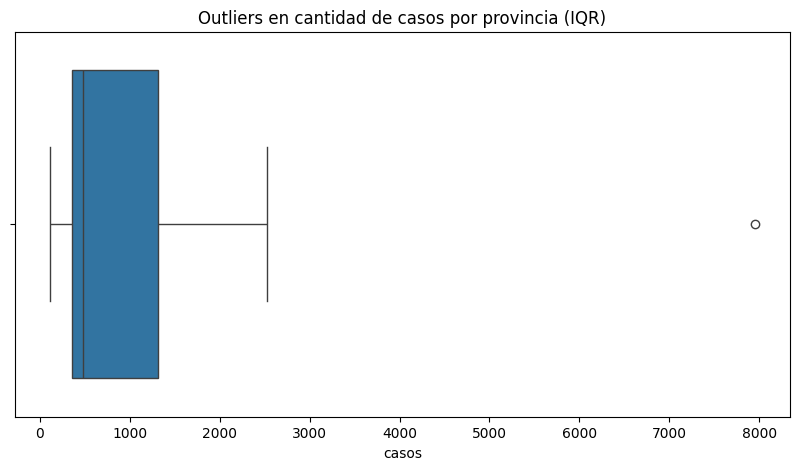

In [35]:
conteos_prov = df.groupby('provincia_nombre').size().reset_index(name='casos')
Q1 = conteos_prov['casos'].quantile(0.25)
Q3 = conteos_prov['casos'].quantile(0.75)
IQR = Q3 - Q1
low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
conteos_prov['es_outlier'] = (conteos_prov['casos'] < low) | (conteos_prov['casos'] > high)
print("🔹 Provincias outliers:")
display(conteos_prov[conteos_prov['es_outlier']].sort_values('casos', ascending=False))
plt.figure(figsize=(10,5))
sns.boxplot(data=conteos_prov, x='casos')
plt.title("Outliers en cantidad de casos por provincia (IQR)")
plt.show()